In [136]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import random_split

In [137]:
# 1. 사용할 디바이스 지정 (NVIDIA GPU -> Mac GPU -> CPU 순서)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():  # M1/M2/M3 맥북 유저용
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"현재 사용 중인 디바이스: {device}")

현재 사용 중인 디바이스: cuda


### 학습 데이터 설정


In [138]:
train_dataset = datasets.CIFAR10(
    root="data/cifar10_data/",
    train=True,
    transform=transforms.ToTensor(),
    download=True,
)
test_dataset = datasets.CIFAR10(
    root="data/cifar10_data/",
    train=False,
    transform=transforms.ToTensor(),
    download=True,
)

In [139]:
train_dataset_size = int(len(train_dataset) * 0.80)
validation_dataset_size = len(train_dataset) - train_dataset_size

train_dataset, validation_dataset = random_split(
    train_dataset, [train_dataset_size, validation_dataset_size]
)

print(len(train_dataset), len(validation_dataset), len(test_dataset))

40000 10000 10000


In [140]:
BATCH_SIZE = 64

train_dataset_loader = DataLoader(
    dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True
)
validation_dataset_loader = DataLoader(
    dataset=validation_dataset, batch_size=BATCH_SIZE, shuffle=True
)
test_dataset_loader = DataLoader(
    dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False
)

### 데이터 확인


In [141]:
classes = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)

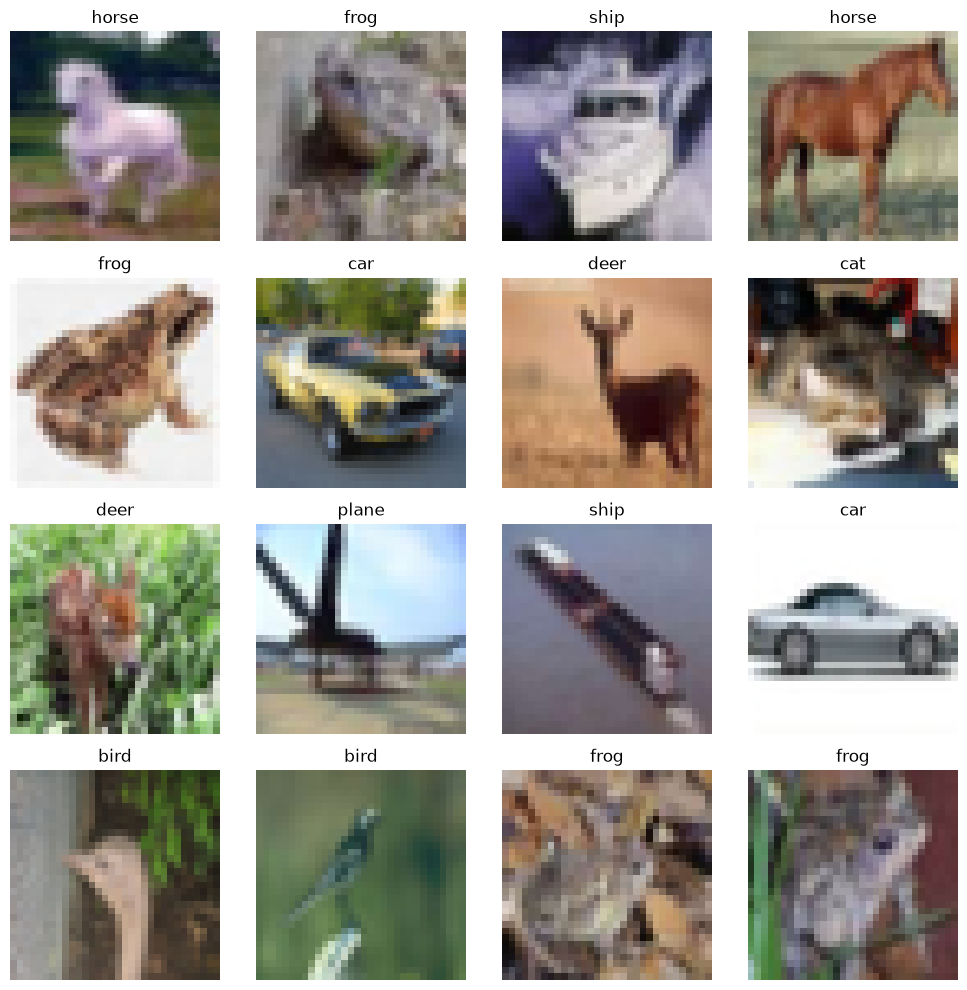

In [142]:
sample_data = next(iter(train_dataset_loader))

plt.figure(figsize=(10, 10))

for idx in range(16):
    images, labels = sample_data
    npimg = images[idx].numpy()

    plt.subplot(4, 4, idx + 1)

    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(classes[labels[idx].item()])

    plt.axis("off")

plt.tight_layout()
plt.show()

### 모델 생성


In [143]:
class CnnModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.3),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.3),
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.3),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.3),
        )
        self.linear_block = nn.Sequential(
            nn.Linear(2 * 2 * 256, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 10),
        )

    def forward(self, data):
        data = self.conv_block(data)
        data = data.view(-1, 2 * 2 * 256)
        data = self.linear_block(data)
        return         data

In [144]:
model = CnnModel()

loss_function = (
    nn.CrossEntropyLoss()
)  # CrossEntropyLoss 손실함수에는 softmax 함수 포함되어 있음
optim = torch.optim.Adam(model.parameters(), lr=1e-3)

In [145]:
from torchinfo import summary

summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
CnnModel                                 [1, 10]                   --
├─Sequential: 1-1                        [1, 256, 2, 2]            --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           896
│    └─ReLU: 2-2                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-3                       [1, 64, 32, 32]           18,496
│    └─ReLU: 2-4                         [1, 64, 32, 32]           --
│    └─MaxPool2d: 2-5                    [1, 64, 16, 16]           --
│    └─Dropout: 2-6                      [1, 64, 16, 16]           --
│    └─Conv2d: 2-7                       [1, 64, 16, 16]           36,928
│    └─ReLU: 2-8                         [1, 64, 16, 16]           --
│    └─Conv2d: 2-9                       [1, 128, 16, 16]          73,856
│    └─ReLU: 2-10                        [1, 128, 16, 16]          --
│    └─MaxPool2d: 2-11                   [1, 128, 8, 8]            --
│ 

### 학습 및 검증 함수 선언


In [146]:
def model_train(
    dataloader: DataLoader,
    model: CnnModel,
    loss_function: nn.CrossEntropyLoss,
    optim: torch.optim.SGD,
):

    model.train()

    loss_sum = train_correct = total_count = 0
    batch_count = len(dataloader)

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = loss_function(outputs, labels)

        optim.zero_grad()
        loss.backward()
        optim.step()

        loss_sum += loss.item()

        total_count += labels.size(0)
        train_correct += ((torch.argmax(outputs, 1) == labels)).sum().item()

    avg_loss = loss_sum / batch_count
    avg_accuracy = 100 * train_correct / total_count

    return (avg_loss, avg_accuracy)

In [147]:
def model_evaluate(
    dataloader: DataLoader,
    model: CnnModel,
    loss_function: nn.CrossEntropyLoss,
):

    model.eval()

    with torch.no_grad():

        loss_sum = correct_list = total_count = 0
        batch_count = len(dataloader)

        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_function(outputs, labels)

            loss_sum += loss.item()

            total_count += labels.size(0)
            correct_list += ((torch.argmax(outputs, 1) == labels)).sum().item()

        avg_loss = loss_sum / batch_count
        avg_accuracy = 100 * correct_list / total_count

    return (avg_loss, avg_accuracy)

In [148]:
def model_test(
    dataloader: DataLoader,
    model: CnnModel,
    loss_function: nn.CrossEntropyLoss,
):

    model.eval()

    with torch.no_grad():

        loss_sum = correct_list = total_count = 0
        batch_count = len(dataloader)

        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_function(outputs, labels)

            loss_sum += loss.item()

            total_count += labels.size(0)
            correct_list += ((torch.argmax(outputs, 1) == labels)).sum().item()

        avg_loss = loss_sum / batch_count
        avg_accuracy = 100 * correct_list / total_count

    print("accuracy:", avg_accuracy)
    print("loss:", avg_loss)

In [149]:
train_loss_list = []
train_accuracy_list = []

val_loss_list = []
val_accuracy_list = []

EPOCHS = 100

for epoch in range(EPOCHS):

    # ================== model train ======================
    train_avg_loss, train_avg_accuracy = model_train(
        train_dataset_loader, model, loss_function, optim
    )

    train_loss_list.append(train_avg_loss)
    train_accuracy_list.append(train_avg_accuracy)
    # =====================================================

    # ================== model evaluation =================
    val_avg_loss, val_avg_accuracy = model_evaluate(
        validation_dataset_loader, model, loss_function
    )

    val_loss_list.append(val_avg_loss)
    val_accuracy_list.append(val_avg_accuracy)
    # =====================================================

    print(
        f"epoch: {epoch}, train loss= {train_avg_loss:.4f}, train accuracy= {train_avg_accuracy:.4f},"
        f"validation loss= {val_avg_loss:.4f}, validation accuracy= {val_avg_accuracy:.4f}"
    )

epoch: 0, train loss= 1.8688, train accuracy= 28.0200,validation loss= 1.5769, validation accuracy= 41.6600
epoch: 1, train loss= 1.4284, train accuracy= 47.2075,validation loss= 1.2629, validation accuracy= 54.1200
epoch: 2, train loss= 1.2315, train accuracy= 55.5475,validation loss= 1.0975, validation accuracy= 61.1600


KeyboardInterrupt: 

### Loss 및 Accuracy 히스토리


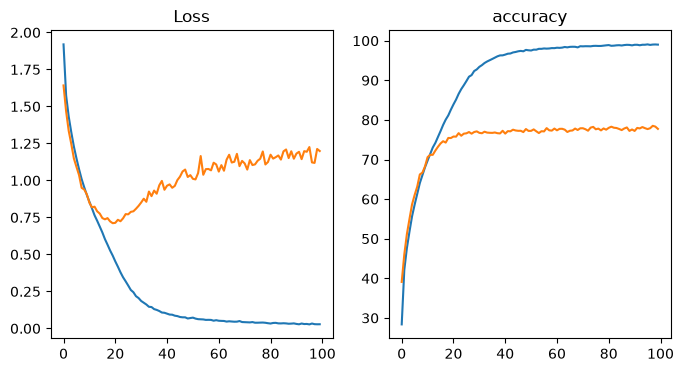

In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.plot(train_loss_list)
plt.plot(val_loss_list)
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(train_accuracy_list)
plt.plot(val_accuracy_list)
plt.title("accuracy")

plt.show()

### 모델 테스트


In [ ]:
model_test(test_dataset_loader, model, loss_function)

accuracy: 77.31
loss: 1.2099081442993918
